In [214]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset

In [215]:
song_df = pd.read_excel('Song_Dataset.xlsx', sheet_name='Song_Deatils')
song_df.head()

,Song_Id,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode
0,"4,137",Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826.0,125,B,Major
1,"3,628",LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382.0,92,C#,Major
2,"3,520",vampire,Olivia Rodrigo,1,2023,June,30,1397,113,140003974,94,207,91,14,949.0,138,F,Major
3,"3,362",Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548.0,170,A,Major
4,"3,914",WHERE SHE GOES,Bad Bunny,1,2025,May,18,3133,50,303236322,84,133,87,15,425.0,144,A,Minor


In [216]:
node_df = pd.read_excel('Song_Dataset.xlsx', sheet_name='Node_Deatils')
node_df.head()

,Song_Id,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,3788,81.0,97.0,77.0,75.0,0.0,35.0,3.0
1,4709,91.0,97.0,57.0,38.0,0.0,40.0,29.0
2,4087,86.0,97.0,80.0,36.0,0.0,9.0,6.0
3,2258,70.0,97.0,62.0,47.0,0.0,10.0,NaN
4,3911,70.0,NaN,59.0,55.0,0.0,27.0,12.0


In [217]:
song_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Song_Id               949 non-null    object 
 1   track_name            949 non-null    object 
 2   artist(s)_name        949 non-null    object 
 3   artist_count          949 non-null    int64  
 4   released_year         949 non-null    int64  
 5   released_month        949 non-null    object 
 6   released_day          949 non-null    int64  
 7   in_spotify_playlists  949 non-null    int64  
 8   in_spotify_charts     949 non-null    int64  
 9   streams               949 non-null    object 
 10  in_apple_playlists    949 non-null    int64  
 11  in_apple_charts       949 non-null    int64  
 12  in_deezer_playlists   949 non-null    int64  
 13  in_deezer_charts      949 non-null    int64  
 14  in_shazam_charts      898 non-null    float64
 15  bpm                   9

In [218]:
# convert 'streams' column to numeric, coercing errors to NaN
song_df['streams'] = pd.to_numeric(song_df['streams'], errors='coerce')

In [219]:
# convert month names to month numbers
import calendar
def month_to_number(month_name):
    try: 
        return int(month_name) # If it's already a number, return it as an integer
    except:
        try:
            return list(calendar.month_name).index(month_name.capitalize()) # Convert month name to number
        except:
            return None # Return None for invalid month names

song_df['released_month'] = song_df['released_month'].apply(month_to_number)

In [220]:
print(song_df.columns.tolist())

['Song_Id', 'track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode']


In [221]:
date_df = song_df[['released_year','released_month','released_day']].rename(columns={
                            'released_year': 'year',
                            'released_month': 'month',
                            'released_day': 'day'
                        })

song_df['release_date'] = pd.to_datetime(date_df, errors='coerce')

In [222]:
song_df['release_date'].head()

0   2023-07-14
1   2023-03-23
2   2023-06-30
3   2019-08-23
4   2025-05-18
Name: release_date, dtype: datetime64[ns]

In [223]:
song_df.drop(columns=['released_year','released_month','released_day'], inplace=True)

In [224]:
node_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Song_Id             954 non-null    int64  
 1   danceability_%      906 non-null    float64
 2   valence_%           906 non-null    float64
 3   energy_%            907 non-null    float64
 4   acousticness_%      907 non-null    float64
 5   instrumentalness_%  906 non-null    float64
 6   liveness_%          906 non-null    float64
 7   speechiness_%       906 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 59.8 KB


In [225]:
# Display common columns
common_cols = set(song_df.columns).intersection(set(node_df.columns))
print('Common columns:', common_cols)

Common columns: {'Song_Id'}


In [226]:
# removing the commas, convert the column to a numeric type afterward
song_df['Song_Id'] = song_df['Song_Id'].str.replace(',', '')
song_df['Song_Id'] = pd.to_numeric(song_df['Song_Id'], errors='coerce')

In [227]:
# Check unique values in the key column
key_col = 'Song_Id'
if key_col in common_cols:
    print(f'Unique values in {key_col} (song_df):', song_df[key_col].nunique())
    print(f'Unique values in {key_col} (node_df):', node_df[key_col].nunique())

Unique values in Song_Id (song_df): 813
Unique values in Song_Id (node_df): 816


In [228]:
if key_col in common_cols:
    print(f"song_df[{key_col}] total count:", len(song_df[key_col]))
    print(f"node_df[{key_col}] total count:", len(node_df[key_col]))
    
    # Find which keys are missing in either DataFrame
    missing_in_node = set(song_df[key_col]) - set(node_df[key_col])
    missing_in_song = set(node_df[key_col]) - set(song_df[key_col])
    print(f"Keys in song_df but not in node_df: {len(missing_in_node)}")
    print(f"Keys in node_df but not in song_df: {len(missing_in_song)}")

else:
    print('No common columns found to merge on.')

song_df[Song_Id] total count: 949
node_df[Song_Id] total count: 954
Keys in song_df but not in node_df: 4
Keys in node_df but not in song_df: 7


In [229]:
# identify which keys are missing in either DataFrame
only_song = set(song_df['Song_Id']) - set(node_df['Song_Id'])
only_node = set(node_df['Song_Id']) - set(song_df['Song_Id'])

print("Only in song_df:", only_song)
print("Only in node_df:", only_node)

Only in song_df: {3976, 4801, 3659, 4644}
Only in node_df: {4842, 4206, 4367, 2256, 3055, 2484, 3764}


# Handle Duplicate data

In [230]:
song_df[song_df['Song_Id'].duplicated(keep=False)].sort_values('Song_Id')

,Song_Id,track_name,artist(s)_name,artist_count,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,release_date
925,2057,Bamba (feat. Aitch & BIA),"Luciano, Aitch, Bï¿½",3,869,7,146223492.0,14,12,12,2,28.0,138,A#,Major,2022-09-22
11,2057,Super Shy,NewJeans,1,422,55,58255150.0,37,202,21,5,168.0,150,F,Minor,2023-07-07
311,2057,If We Ever Broke Up,Mae Stephens,1,2040,4,165584767.0,81,27,66,9,444.0,116,G,Major,2023-02-10
33,2057,Super Shy,NewJeans,1,422,55,58255150.0,37,202,21,5,168.0,150,F,Minor,2023-07-07
872,2073,Ai Preto,"L7nnon, DJ Biel do Furduncinho, Bianca",3,894,4,176103902.0,28,0,54,0,0.0,130,F#,Major,2022-06-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,4989,En Paris,"El Chachito, Junior H",2,406,5,198275403.0,3,31,2,1,0.0,139,D#,Minor,2022-12-24
612,4989,Take My Breath,The Weeknd,1,6392,0,432702334.0,174,73,344,0,0.0,121,G#,Major,2021-08-06
152,4991,Jimmy Cooks (feat. 21 Savage),"Drake, 21 Savage",2,5871,27,618885532.0,81,121,58,1,34.0,163,NaN,Major,2022-06-17
16,4991,Cupid - Twin Ver.,Fifty Fifty,1,2942,77,496795686.0,91,212,78,6,0.0,120,B,Minor,2023-02-24


In [231]:
# number of unique track names
song_df['track_name'].nunique()

931

In [232]:
song_df[['track_name', 'artist(s)_name', 'release_date']].nunique()

track_name        931
artist(s)_name    639
release_date      477
dtype: int64

In [233]:
song_df[['track_name', 'artist(s)_name', 'release_date']].duplicated().sum()

11

In [234]:
song_df[['track_name', 'artist(s)_name', 'release_date']].drop_duplicates().shape

(938, 3)

In [235]:
node_df[node_df['Song_Id'].duplicated(keep=False)].sort_values('Song_Id')

,Song_Id,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
328,2040,85.0,80.0,83.0,10.0,0.0,8.0,11.0
121,2040,85.0,80.0,83.0,10.0,0.0,8.0,11.0
464,2057,78.0,52.0,82.0,18.0,0.0,15.0,7.0
108,2057,80.0,82.0,81.0,14.0,0.0,13.0,36.0
96,2073,95.0,83.0,57.0,54.0,0.0,10.0,25.0
...,...,...,...,...,...,...,...,...
147,4989,70.0,77.0,48.0,37.0,0.0,12.0,NaN
458,4989,75.0,53.0,74.0,2.0,0.0,11.0,5.0
628,4991,54.0,40.0,67.0,0.0,0.0,9.0,17.0
155,4991,78.0,NaN,59.0,43.0,0.0,34.0,3.0


In [236]:
node_df.nunique()

Song_Id               816
danceability_%         72
valence_%              94
energy_%               80
acousticness_%         97
instrumentalness_%     37
liveness_%             65
speechiness_%          48
dtype: int64

In [237]:
node_df[['Song_Id','danceability_%', 'valence_%']].duplicated().sum()

10

In [238]:
node_df[['Song_Id','danceability_%', 'valence_%']].drop_duplicates().shape

(944, 3)

# Handle Null Values

In [239]:
song_df.isnull().sum()

Song_Id                  0
track_name               0
artist(s)_name           0
artist_count             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  1
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        51
bpm                      0
key                     96
mode                     0
release_date             0
dtype: int64

In [240]:
song_df.fillna({'in_shazam_charts': 0, 'key': 'Unknown'}, inplace=True)

In [241]:
node_df.isnull().sum()

Song_Id                0
danceability_%        48
valence_%             48
energy_%              47
acousticness_%        47
instrumentalness_%    48
liveness_%            48
speechiness_%         48
dtype: int64

In [242]:
cols = [
    'danceability_%','valence_%','energy_%',
    'acousticness_%','instrumentalness_%',
    'liveness_%','speechiness_%'
]

node_df[cols] = node_df[cols].fillna(node_df[cols].mean())

# Merging

In [243]:
df = pd.merge(song_df, node_df, on='Song_Id', how='inner')
df.head()

,Song_Id,track_name,artist(s)_name,artist_count,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,...,key,mode,release_date,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,4137,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,553,147,141381703.0,43,263,45,...,B,Major,2023-07-14,66.94702,89.0,83.0,26.994487,0.0,8.0,4.000000
1,3628,LALA,Myke Towers,1,1474,48,133716286.0,48,126,58,...,C#,Major,2023-03-23,71.00000,61.0,74.0,7.000000,0.0,10.0,10.101545
2,3628,LALA,Myke Towers,1,1474,48,133716286.0,48,126,58,...,C#,Major,2023-03-23,80.00000,24.0,65.0,26.994487,0.0,9.0,4.000000
3,3628,Freaky Deaky,"Tyga, Doja Cat",2,1729,0,153240879.0,26,1,19,...,D,Minor,2022-02-25,71.00000,61.0,74.0,7.000000,0.0,10.0,10.101545
4,3628,Freaky Deaky,"Tyga, Doja Cat",2,1729,0,153240879.0,26,1,19,...,D,Minor,2022-02-25,80.00000,24.0,65.0,26.994487,0.0,9.0,4.000000


In [244]:
df.shape

(1234, 23)

In [245]:
df.isnull().sum()

Song_Id                 0
track_name              0
artist(s)_name          0
artist_count            0
in_spotify_playlists    0
in_spotify_charts       0
streams                 1
in_apple_playlists      0
in_apple_charts         0
in_deezer_playlists     0
in_deezer_charts        0
in_shazam_charts        0
bpm                     0
key                     0
mode                    0
release_date            0
danceability_%          0
valence_%               0
energy_%                0
acousticness_%          0
instrumentalness_%      0
liveness_%              0
speechiness_%           0
dtype: int64

# EDA

In [246]:
df.describe()

,Song_Id,artist_count,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,release_date,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,1234.000000,1234.000000,1234.000000,1234.000000,1.233000e+03,1234.000000,1234.000000,1234.000000,1234.000000,1234.000000,1234.000000,1234,1234.000000,1234.000000,1234.000000,1234.000000,1234.000000,1234.000000,1234.000000
mean,3445.642626,1.542139,5044.776337,12.132091,5.089966e+08,66.297407,51.861426,369.759319,2.699352,59.992707,122.435981,2018-11-27 14:25:52.025932032,67.489234,51.824439,64.216477,27.155288,1.485284,18.038349,10.290600
min,2000.000000,1.000000,34.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,1930-01-01 00:00:00,23.000000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,2696.000000,1.000000,873.000000,0.000000,1.462235e+08,13.000000,7.000000,13.000000,0.000000,0.000000,100.000000,2020-09-06 18:00:00,59.000000,35.000000,55.000000,6.000000,0.000000,10.000000,4.000000
50%,3415.500000,1.000000,2178.500000,3.000000,2.881017e+08,34.000000,36.500000,44.500000,0.000000,2.000000,121.000000,2022-04-13 12:00:00,69.000000,51.439294,65.000000,20.000000,0.000000,13.000000,6.000000
75%,4227.750000,2.000000,5412.000000,16.000000,6.657656e+08,85.000000,84.000000,168.000000,2.000000,32.750000,140.000000,2022-11-04 00:00:00,78.000000,70.000000,76.000000,41.000000,0.000000,23.000000,11.000000
max,4997.000000,8.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,12367.000000,58.000000,1451.000000,206.000000,2028-06-02 00:00:00,96.000000,97.000000,97.000000,97.000000,91.000000,91.000000,64.000000
std,868.357361,0.860180,7651.110575,20.255294,5.551114e+08,84.164786,52.055848,1087.695864,6.223432,172.173174,27.917609,NaN,14.427541,22.674570,16.235509,25.575394,7.762555,12.947115,9.740612


c:\Users\asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


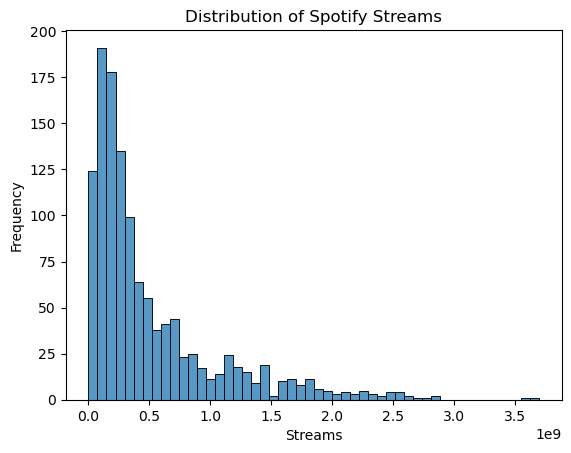

In [247]:
sns.histplot(df['streams'], bins=50)
plt.title("Distribution of Spotify Streams")
plt.xlabel("Streams")
plt.ylabel("Frequency")
plt.show()

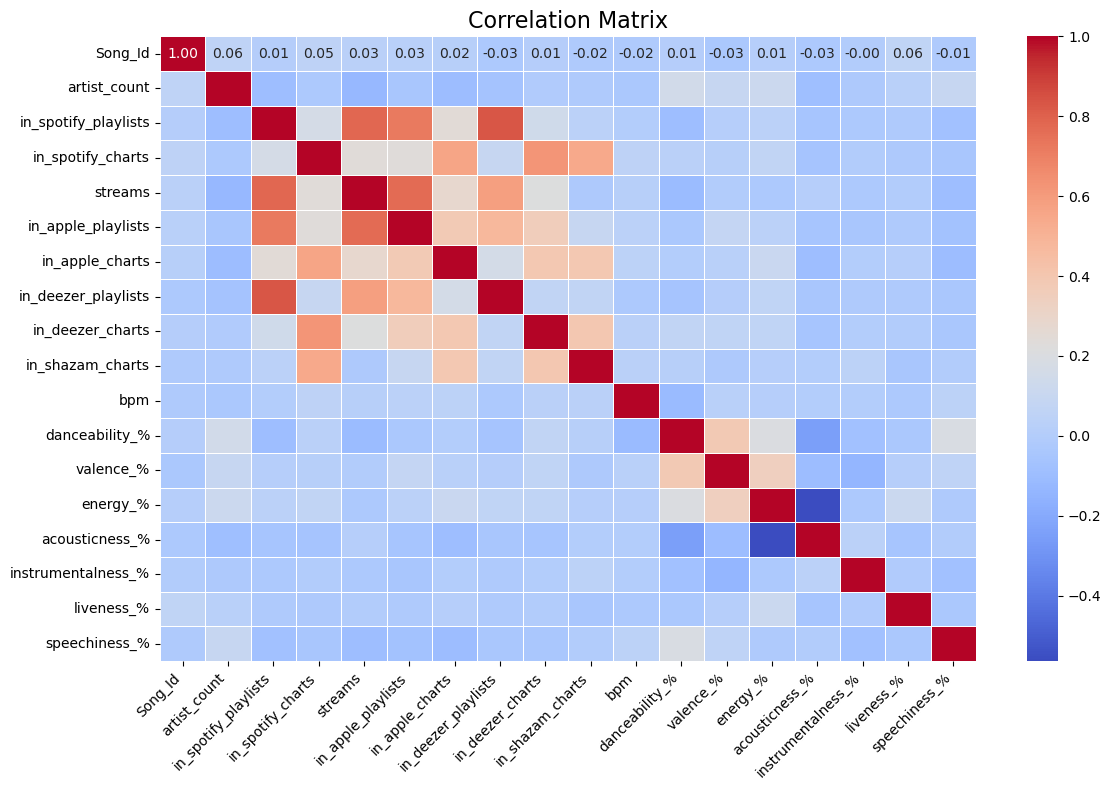

In [248]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size": 10}
)
plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature Selection

In [249]:
df['streams'].isnull().sum()

1

In [250]:
df = df.dropna(subset=['streams'])

In [251]:
from sklearn.ensemble import RandomForestRegressor

features = [
    'in_spotify_playlists',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_shazam_charts',
    'in_spotify_charts','in_deezer_charts',
    'energy_%','danceability_%','valence_%'
]

X = df[features]
y = df['streams']

model = RandomForestRegressor()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

in_spotify_playlists    0.396400
in_deezer_playlists     0.393952
in_apple_playlists      0.088094
in_spotify_charts       0.030866
in_apple_charts         0.018361
in_shazam_charts        0.017780
danceability_%          0.014306
valence_%               0.014177
energy_%                0.014176
in_deezer_charts        0.011890
dtype: float64


<Axes: xlabel='in_spotify_playlists', ylabel='streams'>

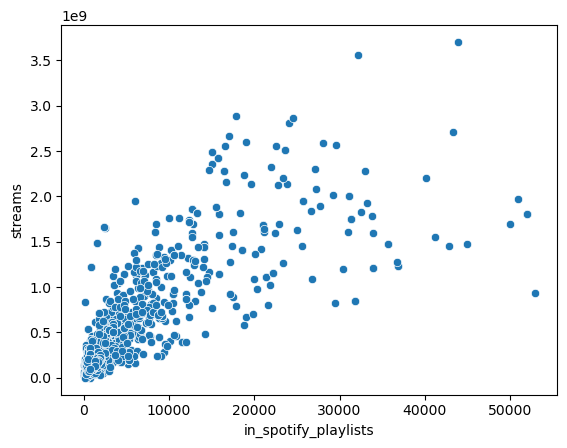

In [252]:
sns.scatterplot(data=df, x='in_spotify_playlists', y='streams')

In [253]:
df[['in_spotify_playlists','in_apple_playlists','streams']].corr()

,in_spotify_playlists,in_apple_playlists,streams
in_spotify_playlists,1.000000,0.718911,0.784366
in_apple_playlists,0.718911,1.000000,0.768957
streams,0.784366,0.768957,1.000000


c:\Users\asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\asus\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

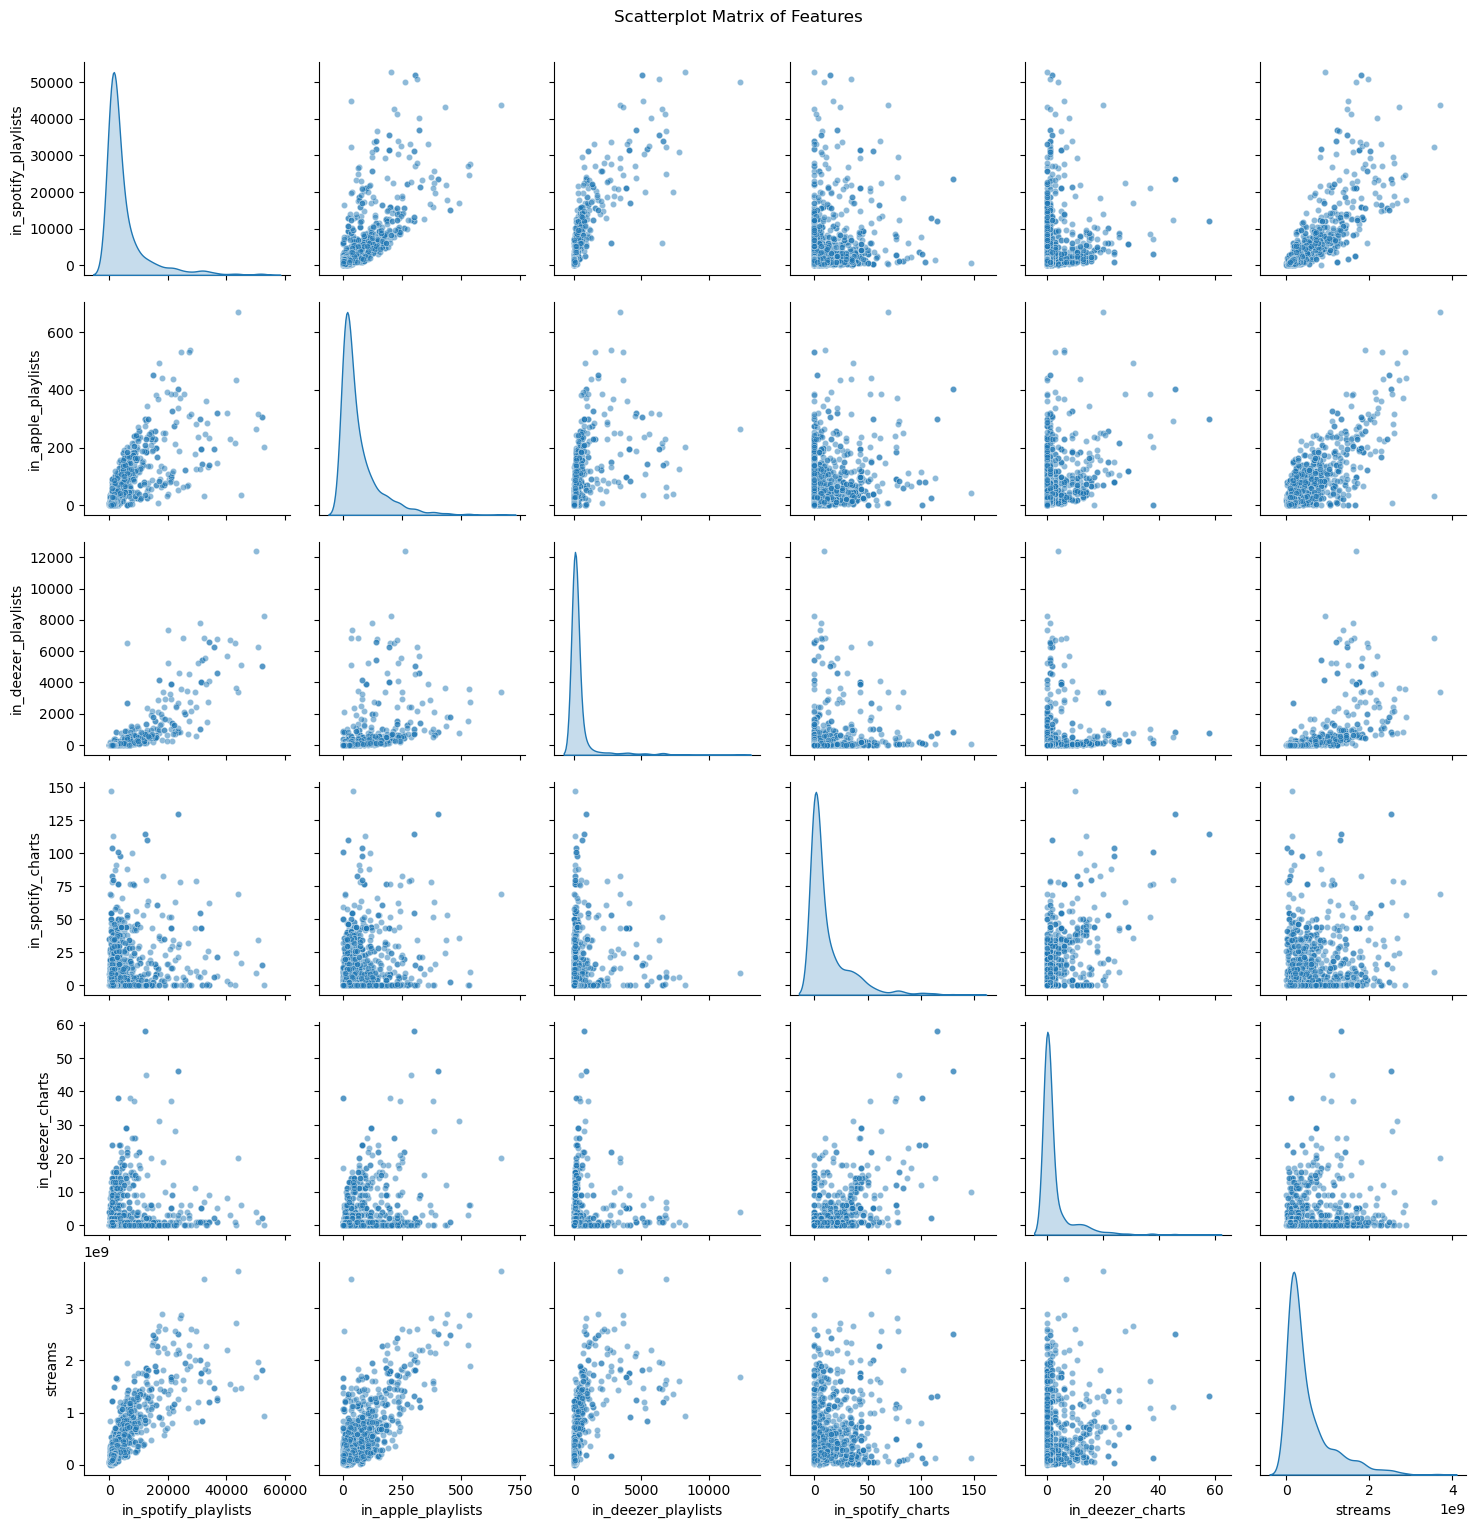

In [254]:
plot_features = [
    'in_spotify_playlists',
    'in_apple_playlists',
    'in_deezer_playlists',
    'in_spotify_charts',
    'in_deezer_charts',
    'streams'
]

# Create pairplot (scatterplot matrix)
sns.pairplot(df[plot_features], diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
plt.suptitle("Scatterplot Matrix of Features", y=1.02)
plt.show()

Transform the relationship

In [255]:
df['log_streams'] = np.log1p(df['streams'])

<Axes: xlabel='in_spotify_playlists', ylabel='log_streams'>

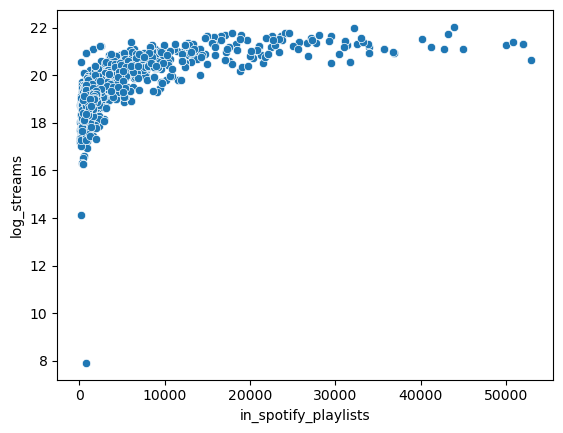

In [256]:
sns.scatterplot(data=df, x='in_spotify_playlists', y='log_streams')

# Preparing the Data for ML

In [257]:
# # top 20% trending songs based on streams
# df['trending'] = df['streams'] > df['streams'].quantile(0.80)
# df['trending'].head()

Scaling Features

In [258]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [259]:
# top 20% trending songs based on streams
df['trending'] = df['streams'] > df['streams'].quantile(0.80)
y = df['trending']

Train Model

In [260]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [261]:
# add a new column with the predicted probabilities of being trending
df['trend_score'] = model.predict_proba(X_scaled)[:, 1]

In [262]:
# Rank Songs
top_trending = df.sort_values('trend_score', ascending=False)
top_trending.head(10)

,Song_Id,track_name,artist(s)_name,artist_count,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,...,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,log_streams,trending,trend_score
133,3869,Heat Waves,Glass Animals,1,22543,63,2.557976e+09,386,144,707,...,76.0,53.0,53.00000,44.0,0.0,9.000000,9.0,21.662482,True,1.0
115,3432,Blinding Lights,The Weeknd,1,43899,69,3.703895e+09,672,199,3421,...,50.0,38.0,80.00000,0.0,0.0,9.000000,7.0,22.032651,True,1.0
292,2831,We Found Love,"Rihanna, Calvin Harris",2,36843,21,1.235006e+09,321,91,4607,...,73.0,60.0,77.00000,3.0,0.0,11.000000,4.0,20.934341,True,1.0
840,4442,Seï¿½ï¿½o,"Shawn Mendes, Camila Cabello",2,15010,2,2.484813e+09,453,50,1785,...,76.0,77.0,52.00000,4.0,0.0,8.000000,3.0,21.633463,True,1.0
959,4321,In Da Club,50 Cent,1,30427,7,1.202723e+09,235,106,5221,...,90.0,79.0,71.00000,26.0,0.0,18.118102,37.0,20.907854,True,1.0
886,2694,Rolling in the Deep,Adele,1,35684,6,1.472800e+09,195,125,6280,...,73.0,52.0,76.00000,13.0,0.0,5.000000,3.0,21.110431,True,1.0
33,4635,As It Was,Harry Styles,1,23575,130,2.513188e+09,403,198,863,...,52.0,66.0,73.00000,34.0,0.0,31.000000,6.0,21.644818,True,1.0
32,4635,As It Was,Harry Styles,1,23575,130,2.513188e+09,403,198,863,...,52.0,66.0,73.00000,34.0,0.0,31.000000,6.0,21.644818,True,1.0
293,2831,We Found Love,"Rihanna, Calvin Harris",2,36843,21,1.235006e+09,321,91,4607,...,65.0,37.0,64.24366,2.0,0.0,4.000000,31.0,20.934341,True,1.0
774,2030,Pepas,Farruko,1,14114,17,1.309887e+09,252,109,965,...,76.0,44.0,77.00000,1.0,0.0,13.000000,3.0,20.993207,True,1.0


In [263]:
# Feture importance
importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))

in_spotify_playlists    0.324228
in_deezer_playlists     0.266072
in_apple_playlists      0.155915
in_spotify_charts       0.053898
in_apple_charts         0.045430
danceability_%          0.038632
valence_%               0.037215
energy_%                0.031793
in_shazam_charts        0.026614
in_deezer_charts        0.020203
dtype: float64
